# GSEA pathway analysis

Investigate to which extend functional annotations agree between modalities.

GSEA analysis was run in `study_05_multimodal.ipynb`

In [46]:
import alphapepttools as apt
import matplotlib.patches as mpatches
import matplotlib.pyplot as plt
import mudata as md
import numpy as np
import pandas as pd
from matplotlib_venn import venn3
from sklearn.preprocessing import MultiLabelBinarizer

In [47]:
# Mirror the central alphapepttools plot settings (defaults.PlotSettings) onto matplotlib's
# global rcParams so notebook figures match the library defaults.
from alphapepttools.pl import defaults

_plot_config = defaults.plot_settings.to_dict()
plt.rcParams.update(
    {
        "font.size": _plot_config["font_sizes"]["medium"],
        "axes.titlesize": _plot_config["axes"]["title_size"],
        "axes.labelsize": _plot_config["axes"]["label_size"],
        "xtick.labelsize": _plot_config["axes"]["tick_size"],
        "ytick.labelsize": _plot_config["axes"]["tick_size"],
        "legend.fontsize": _plot_config["legend"]["font_size"],
        "legend.title_fontsize": _plot_config["legend"]["title_size"],
        "lines.linewidth": _plot_config["linewidths"]["medium"],
        "lines.markersize": _plot_config["marker_sizes"]["medium"],
        "figure.dpi": _plot_config["resolution"]["dpi"],
        "savefig.dpi": _plot_config["resolution"]["dpi"],
        "svg.fonttype": "none",
        "pdf.fonttype": 42,
        "ps.fonttype": 42,
    }
)

In [48]:
# Shared color scheme for the omics modalities, reused across loading and enrichment plots
palette = {"proteins": "#9ED8CB", "rna": "#BDCEE5", "methylation": "#D5BDDE"}
dark_palette = {"proteins": "#4B9384", "rna": "#468FF5", "methylation": "#682381"}

In [49]:
mdata = md.read_h5mu("../data/pp/lehtio2021_nsclc_multimodal.h5mu")

/Users/lucas-diedrich/mamba/envs/at-paper/lib/python3.13/site-packages/anndata/_core/anndata.py:1825: UserWarning: Variable names are not unique. To make them unique, call `.var_names_make_unique`.
  utils.warn_names_duplicates("var")
/Users/lucas-diedrich/mamba/envs/at-paper/lib/python3.13/site-packages/mudata/_core/mudata.py:1403: FutureWarning: From 0.4 .update() will not pull obs/var columns from individual modalities by default anymore. Set mudata.set_options(pull_on_update=False) to adopt the new behaviour, which will become the default. Use new pull_obs/pull_var and push_obs/push_var methods for more flexibility.
  self._update_attr("var", axis=0, join_common=join_common)
/Users/lucas-diedrich/mamba/envs/at-paper/lib/python3.13/site-packages/mudata/_core/mudata.py:571: UserWarning: var_names are not unique. To make them unique, call `.var_names_make_unique`.
  self._update_attr_legacy(attr, axis, join_common, **kwargs)
/Users/lucas-diedrich/mamba/envs/at-paper/lib/python3.13/sit

In [50]:
def plot_modality_loadings(
    data: pd.DataFrame,
    *,
    score: str,
    feature: str,
    palette: dict,
    modality_column: str = "modality",
    xlabel: str = "Score",
    ax: plt.Axes | None = None,
    fontsize: int = 5,
) -> plt.Axes:
    """Horizontal bar plot of per-feature scores, colored by omics modality.

    Used to display either MOFA+ factor loadings or gene set enrichment scores. Each
    bar corresponds to a single feature (a gene or a pathway) and is colored by the
    modality it originates from.

    Parameters
    ----------
    data
        Long-format dataframe with one row per feature.
    score
        Column holding the numeric value drawn as bar length (x-axis).
    feature
        Column holding the feature labels shown on the y-axis.
    palette
        Mapping of modality name to color.
    modality_column
        Column holding the modality of each feature.
    xlabel
        Label of the x-axis.
    ax
        Axes to draw on. If `None`, a new figure and axes are created.

    Notes
    -----
    Feature labels that occur more than once in `data` (e.g. a pathway or gene shared
    across modalities) are rendered in bold to highlight cross-modal agreement.
    """
    data = data.sort_values(by=score)
    colors = data[modality_column].map(palette)

    if ax is None:
        _, ax = plt.subplots(figsize=(4, 8))

    ax.barh(range(len(data)), data[score], color=colors)
    ax.set_yticks(range(len(data)))
    labels = ax.set_yticklabels(data[feature], fontsize=fontsize)

    # Highlight features that occur in more than one row (e.g. shared across modalities)
    feature_counts = data[feature].value_counts()
    for label, name in zip(labels, data[feature], strict=True):
        if feature_counts[name] > 1:
            label.set_fontweight("bold")
    ax.axvline(0, color="black", linewidth=0.8)  # zero reference line
    ax.set_xlabel(xlabel, labelpad=0)

    # Legend mapping each color back to its modality
    handles = [
        mpatches.Patch(color=color, label=modality)
        for modality, color in palette.items()
    ]
    ax.legend(
        handles=handles, title="Modality", bbox_to_anchor=(1.01, 1), loc="upper left"
    )

    ax.spines[["top", "right"]].set_visible(False)
    return ax

## Parameters

In [51]:
OVERLAP_THRESHOLD = None

# Parameters
FACTOR = 2  # zero indexed, referred to as Factor 3 in the paper
SIGNIFICANCE_THRESHOLD = 1e-3

## Get pathway database

In [52]:
pathway_database = "hallmark"
gsea_results = pd.read_csv(
    f"../data/results/gsea-results.{pathway_database}.tsv", sep="\t", index_col=0
)
gsea_results

,factor,pathway,score,pval_adj,modality
0,0,HALLMARK_ADIPOGENESIS,-1.084259,0.784876,methylation
1,1,HALLMARK_ADIPOGENESIS,-1.162857,0.212362,methylation
2,2,HALLMARK_ADIPOGENESIS,-1.031550,0.923214,methylation
3,3,HALLMARK_ADIPOGENESIS,-0.948506,0.856833,methylation
4,4,HALLMARK_ADIPOGENESIS,-1.014372,1.000000,methylation
...,...,...,...,...,...
1245,20,HALLMARK_XENOBIOTIC_METABOLISM,1.583415,0.000000,rna
1246,21,HALLMARK_XENOBIOTIC_METABOLISM,1.429975,0.060680,rna
1247,22,HALLMARK_XENOBIOTIC_METABOLISM,-1.101423,0.596774,rna
1248,23,HALLMARK_XENOBIOTIC_METABOLISM,0.815107,1.000000,rna


In [53]:
# methylation is anticorrelated
gsea_results["score"] = gsea_results.apply(
    lambda row: -row["score"] if row["modality"] in ["methylation"] else row["score"],
    axis=1,
)

In [54]:
significant_pathways = (
    gsea_results.loc[
        (gsea_results["pval_adj"] <= SIGNIFICANCE_THRESHOLD)
        & (gsea_results["score"] > 0)
    ]
    .groupby("factor")
    .apply(
        lambda df: df.pivot_table(
            index="factor", columns="modality", values="pathway", aggfunc=list
        ).reset_index(level=0)
    )
    .reset_index(drop=True)
)

significant_pathways

/var/folders/py/838_q5nd6594y27wbrpkhl3h0000gn/T/ipykernel_63474/1043955516.py:7: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(


modality,factor,proteins,rna,methylation
0,0,"[HALLMARK_ADIPOGENESIS, HALLMARK_APICAL_JUNCTI...","[HALLMARK_ADIPOGENESIS, HALLMARK_ALLOGRAFT_REJ...",NaN
1,1,"[HALLMARK_ADIPOGENESIS, HALLMARK_CHOLESTEROL_H...","[HALLMARK_FATTY_ACID_METABOLISM, HALLMARK_OXID...","[HALLMARK_ESTROGEN_RESPONSE_EARLY, HALLMARK_GL..."
2,2,"[HALLMARK_APICAL_JUNCTION, HALLMARK_APICAL_SUR...","[HALLMARK_FATTY_ACID_METABOLISM, HALLMARK_GLYC...",NaN
3,3,"[HALLMARK_GLYCOLYSIS, HALLMARK_MTORC1_SIGNALIN...","[HALLMARK_FATTY_ACID_METABOLISM, HALLMARK_GLYC...",NaN
4,4,[HALLMARK_E2F_TARGETS],NaN,[HALLMARK_EPITHELIAL_MESENCHYMAL_TRANSITION]
5,6,"[HALLMARK_ALLOGRAFT_REJECTION, HALLMARK_APOPTO...","[HALLMARK_ALLOGRAFT_REJECTION, HALLMARK_APOPTO...",NaN
6,7,"[HALLMARK_ADIPOGENESIS, HALLMARK_E2F_TARGETS, ...",NaN,[HALLMARK_INTERFERON_ALPHA_RESPONSE]
7,8,[HALLMARK_OXIDATIVE_PHOSPHORYLATION],"[HALLMARK_E2F_TARGETS, HALLMARK_FATTY_ACID_MET...",[HALLMARK_PI3K_AKT_MTOR_SIGNALING]
8,10,[HALLMARK_PROTEIN_SECRETION],NaN,NaN
9,11,"[HALLMARK_GLYCOLYSIS, HALLMARK_INTERFERON_GAMM...","[HALLMARK_PANCREAS_BETA_CELLS, HALLMARK_SPERMA...",NaN


/Users/lucas-diedrich/mamba/envs/at-paper/lib/python3.13/site-packages/matplotlib_venn/layout/venn3/pairwise.py:111: UserWarning: Circle C has zero area.
  warnings.warn("Circle C has zero area.")


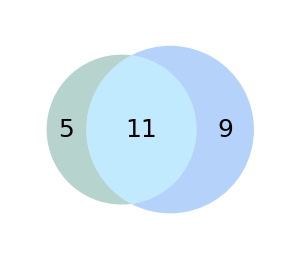

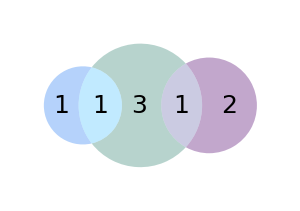

/Users/lucas-diedrich/mamba/envs/at-paper/lib/python3.13/site-packages/matplotlib_venn/layout/venn3/pairwise.py:111: UserWarning: Circle C has zero area.
  warnings.warn("Circle C has zero area.")


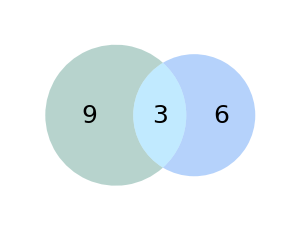

/Users/lucas-diedrich/mamba/envs/at-paper/lib/python3.13/site-packages/matplotlib_venn/layout/venn3/pairwise.py:111: UserWarning: Circle C has zero area.
  warnings.warn("Circle C has zero area.")


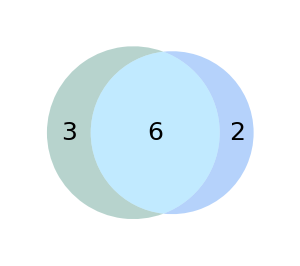

/Users/lucas-diedrich/mamba/envs/at-paper/lib/python3.13/site-packages/matplotlib_venn/layout/venn3/pairwise.py:107: UserWarning: Circle B has zero area.
  warnings.warn("Circle B has zero area.")


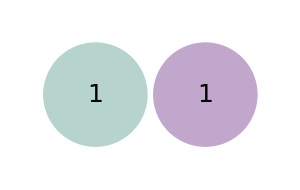

/Users/lucas-diedrich/mamba/envs/at-paper/lib/python3.13/site-packages/matplotlib_venn/layout/venn3/pairwise.py:111: UserWarning: Circle C has zero area.
  warnings.warn("Circle C has zero area.")


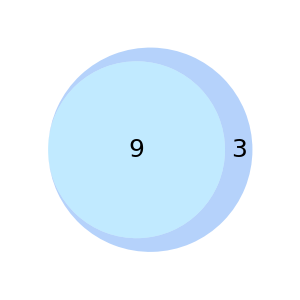

In [55]:
for _, r in significant_pathways.sort_values(by="factor").iterrows():
    row = r.to_dict()
    protein, rna, methylation = row["proteins"], row["rna"], row["methylation"]

    if isinstance(protein, float):
        protein = []

    if isinstance(rna, float):
        rna = []
    if isinstance(methylation, float):
        methylation = []

    fig, ax = apt.pl.create_figure(1, 1, figsize=("0.25", "0.25"))
    venn3(
        (set(protein), set(rna), set(methylation)),
        set_labels=None,
        set_colors=dark_palette.values(),
    )

    fig.savefig(
        f"../data/plots/gsea-{pathway_database}.factor-{row['factor']}-overlap.png",
        transparent=True,
        dpi=600,
    )

    plt.show()

    if row["factor"] > 5:
        break

## Confirm for non-redundant genesets
Define non-redundant set of genesets as genesets with an overlap of less than 50% of genes. This is to confirm that differences in the results are not driven by redundant genesets (i.e. a slightly better matching geneset pushes out an almost identical geneset from the "overlapping genesets" OR the overlap is artificially conflated by almost-identical genesets). 

In [56]:
OVERLAP_THRESHOLD = 0.5

In [57]:
network = pd.read_csv(
    f"../data/raw/{pathway_database}.network.tsv", sep="\t", index_col=0
)
network

,target,collection,source
366,A2M,hallmark,HALLMARK_IL6_JAK_STAT3_SIGNALING
466,A2M,hallmark,HALLMARK_COAGULATION
910,AAAS,hallmark,HALLMARK_DNA_REPAIR
1450,AADAT,hallmark,HALLMARK_FATTY_ACID_METABOLISM
3217,AARS1,hallmark,HALLMARK_ALLOGRAFT_REJECTION
...,...,...,...
5889464,ZPBP,hallmark,HALLMARK_SPERMATOGENESIS
5893438,ZW10,hallmark,HALLMARK_E2F_TARGETS
5893457,ZW10,hallmark,HALLMARK_PROTEIN_SECRETION
5893981,ZWINT,hallmark,HALLMARK_DNA_REPAIR


In [58]:
grouped_networks = network.groupby("source").agg({"target": lambda x: set(x)})

# Binary pathway x gene membership matrix from the gene sets (sparse keeps memory low for ~1300 pathways)
mlb = MultiLabelBinarizer(sparse_output=True)
membership = mlb.fit_transform(grouped_networks["target"])

In [59]:
# Pairwise overlap coefficient |A n B| / min(|A|, |B|): a small set fully nested in a larger one scores 1.0,
# which Jaccard would miss because the large union shrinks the ratio.
intersection = (membership @ membership.T).toarray()
sizes = np.asarray(membership.sum(axis=1)).ravel()
overlap = intersection / np.minimum(sizes[:, None], sizes[None, :])
overlap

array([[1.        , 0.00350877, 0.01342282, ..., 0.04166667, 0.        ,
        0.0877193 ],
       [0.00350877, 1.        , 0.04026846, ..., 0.02916667, 0.01388889,
        0.02769231],
       [0.01342282, 0.04026846, 1.        , ..., 0.00671141, 0.        ,
        0.03355705],
       ...,
       [0.04166667, 0.02916667, 0.00671141, ..., 1.        , 0.        ,
        0.06666667],
       [0.        , 0.01388889, 0.        , ..., 0.        , 1.        ,
        0.02777778],
       [0.0877193 , 0.02769231, 0.03355705, ..., 0.06666667, 0.02777778,
        1.        ]], shape=(50, 50))

In [60]:
# Fraction of off-diagonal pairs exceeding the threshold (diagonal is self-overlap = 1.0)
off_diagonal = ~np.eye(len(overlap), dtype=bool)
(overlap[off_diagonal] > OVERLAP_THRESHOLD).mean()

np.float64(0.0016326530612244899)

In [61]:
significant_pathways = gsea_results.loc[
    # (gsea_results["factor"] == FACTOR) &
    (gsea_results["pval_adj"] <= SIGNIFICANCE_THRESHOLD)
].sort_values(by="score")

significant_pathways

,factor,pathway,score,pval_adj,modality
300,0,HALLMARK_E2F_TARGETS,-3.645790,0.0,proteins
425,0,HALLMARK_G2M_CHECKPOINT,-3.397387,0.0,proteins
775,0,HALLMARK_MYC_TARGETS_V1,-2.965475,0.0,proteins
300,0,HALLMARK_E2F_TARGETS,-2.944173,0.0,rna
244,19,HALLMARK_COAGULATION,-2.935316,0.0,proteins
...,...,...,...,...,...
325,0,HALLMARK_EPITHELIAL_MESENCHYMAL_TRANSITION,2.347070,0.0,proteins
306,6,HALLMARK_E2F_TARGETS,2.402572,0.0,proteins
631,6,HALLMARK_INTERFERON_ALPHA_RESPONSE,2.413410,0.0,proteins
656,6,HALLMARK_INTERFERON_GAMMA_RESPONSE,2.442458,0.0,proteins


Hallmark genesets are almost completely disjoint.

In [ ]:
# Gene-set overlap is modality-independent (same pathway -> same genes), but redundancy is collapsed
# separately per modality so each modality's significant pathways drive its own selection.
position = {pathway: i for i, pathway in enumerate(grouped_networks.index)}
mapped = set(grouped_networks.index)

kept_rows = []
for modality, group in significant_pathways.groupby("modality"):
    pathways = group["pathway"].unique()

    # Greedy collapse, largest-first: walk pathways from biggest gene set to smallest and keep one only
    # if it does not overlap an already-kept (larger) pathway beyond the threshold. This keeps the broad
    # parent term of each redundant cluster and drops its more specific members. Pathways without gene
    # mappings have no size, cannot be assessed, and are retained as-is.
    # ordered = sorted(
    #     (p for p in pathways if p in mapped),
    #     key=lambda p: sizes[position[p]],
    #     reverse=False,
    # )

    strength = group.groupby("pathway")["score"].apply(lambda s: s.abs().max())
    ordered = sorted(strength.index, key=lambda p: strength[p], reverse=True)

    kept = [p for p in pathways if p not in mapped]
    kept_idx = []
    for pathway in ordered:
        i = position[pathway]
        if all(overlap[i, j] <= OVERLAP_THRESHOLD for j in kept_idx):
            kept.append(pathway)
            kept_idx.append(i)

    kept_rows.append(group[group["pathway"].isin(set(kept))])
    print(f"{modality}: {len(pathways)} -> {len(kept)} pathways")

non_redundant = pd.concat(kept_rows)
non_redundant

methylation: 14 -> 14 pathways
proteins: 42 -> 40 pathways
rna: 37 -> 35 pathways


,factor,pathway,score,pval_adj,modality
209,9,HALLMARK_CHOLESTEROL_HOMEOSTASIS,-1.773348,0.0,methylation
216,16,HALLMARK_CHOLESTEROL_HOMEOSTASIS,-1.733082,0.0,methylation
26,1,HALLMARK_ALLOGRAFT_REJECTION,-1.701416,0.0,methylation
640,15,HALLMARK_INTERFERON_ALPHA_RESPONSE,-1.607713,0.0,methylation
262,12,HALLMARK_COMPLEMENT,-1.601386,0.0,methylation
...,...,...,...,...,...
790,15,HALLMARK_MYC_TARGETS_V1,2.112199,0.0,rna
440,15,HALLMARK_G2M_CHECKPOINT,2.126655,0.0,rna
1100,0,HALLMARK_TNFA_SIGNALING_VIA_NFKB,2.151238,0.0,rna
315,15,HALLMARK_E2F_TARGETS,2.202017,0.0,rna


/Users/lucas-diedrich/mamba/envs/at-paper/lib/python3.13/site-packages/matplotlib_venn/layout/venn3/pairwise.py:111: UserWarning: Circle C has zero area.
  warnings.warn("Circle C has zero area.")


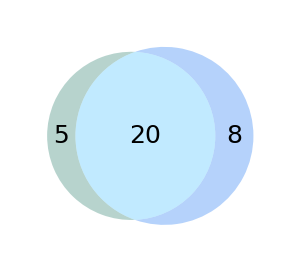

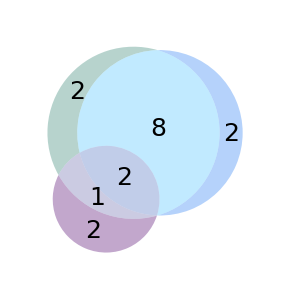

/Users/lucas-diedrich/mamba/envs/at-paper/lib/python3.13/site-packages/matplotlib_venn/layout/venn3/pairwise.py:111: UserWarning: Circle C has zero area.
  warnings.warn("Circle C has zero area.")


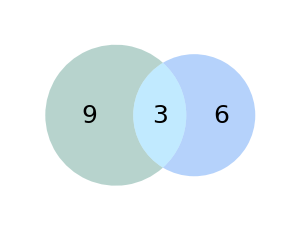

/Users/lucas-diedrich/mamba/envs/at-paper/lib/python3.13/site-packages/matplotlib_venn/layout/venn3/pairwise.py:111: UserWarning: Circle C has zero area.
  warnings.warn("Circle C has zero area.")


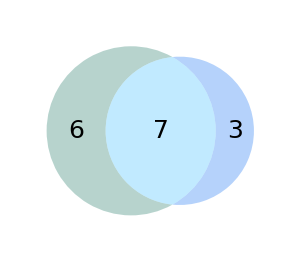

/Users/lucas-diedrich/mamba/envs/at-paper/lib/python3.13/site-packages/matplotlib_venn/layout/venn3/pairwise.py:107: UserWarning: Circle B has zero area.
  warnings.warn("Circle B has zero area.")


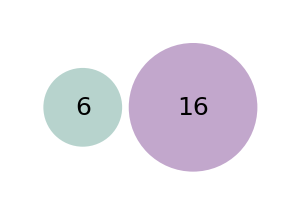

/Users/lucas-diedrich/mamba/envs/at-paper/lib/python3.13/site-packages/matplotlib_venn/layout/venn3/pairwise.py:111: UserWarning: Circle C has zero area.
  warnings.warn("Circle C has zero area.")


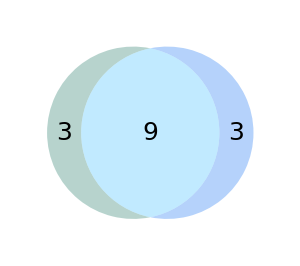

In [63]:
for factor, r in (
    non_redundant.pivot_table(
        index="factor", columns="modality", values="pathway", aggfunc=lambda x: x
    )
    .sort_values(by="factor")
    .iterrows()
):
    row = r.to_dict()
    protein, rna, methylation = row["proteins"], row["rna"], row["methylation"]

    if isinstance(protein, float):
        protein = []

    if isinstance(rna, float):
        rna = []
    if isinstance(methylation, float):
        methylation = []

    fig, ax = apt.pl.create_figure(1, 1, figsize=("0.25", "0.25"))
    venn3(
        (set(protein), set(rna), set(methylation)),
        set_labels=None,
        set_colors=dark_palette.values(),
    )

    # fig.savefig(f"../data/plots/gsea-{pathway_database}.factor-{row['factor']}-overlap.png", transparent=True, dpi=600)

    plt.show()

    if factor > 5:
        break

We obtain qualitatively similar results